In [4]:
import polars as pl
import os

# Diretório dos dados
data_dir = '../data'

# Carregar dados de 2022, 2023 e 2024 (formato antigo - arquivo único)
# Usar separator em vez de sep e ignore_errors para lidar com problemas de parsing
df_2022 = pl.read_csv(f'{data_dir}/microdados_censo_escolar_2022/microdados/dados/microdados_ed_basica_2022.csv', separator=';', encoding='latin-1', ignore_errors=True)
df_2023 = pl.read_csv(f'{data_dir}/microdados_censo_escolar_2023/dados/microdados_ed_basica_2023.csv', separator=';', encoding='latin-1', ignore_errors=True)
df_2024 = pl.read_csv(f'{data_dir}/microdados_censo_escolar_2024/dados/microdados_ed_basica_2024.csv', separator=';', encoding='latin-1', ignore_errors=True)

# Carregar dados de 2025 (novo formato - tabelas separadas)
# Vamos carregar a Tabela_Matricula_2025 que contém as matrículas
df_matricula_2025 = pl.read_csv(f'{data_dir}/microdados_censo_escolar_2025_/microdados_censo_escolar_2025/dados/Tabela_Matricula_2025.csv', separator=';', encoding='latin-1', ignore_errors=True)
df_escola_2025 = pl.read_csv(f'{data_dir}/microdados_censo_escolar_2025_/microdados_censo_escolar_2025/dados/Tabela_Escola_2025.csv', separator=';', encoding='latin-1', ignore_errors=True)

print(f"2022: {df_2022.shape}")
print(f"2023: {df_2023.shape}")
print(f"2024: {df_2024.shape}")
print(f"2025 Matrícula: {df_matricula_2025.shape}")
print(f"2025 Escola: {df_escola_2025.shape}")

2022: (224649, 385)
2023: (217625, 408)
2024: (215545, 426)
2025 Matrícula: (178766, 237)
2025 Escola: (214192, 302)


In [5]:
import pandas as pd

# Converter dataframes Polars para Pandas
df_2022 = df_2022.to_pandas()
df_2023 = df_2023.to_pandas()
df_2024 = df_2024.to_pandas()
df_matricula_2025 = df_matricula_2025.to_pandas()
df_escola_2025 = df_escola_2025.to_pandas()

# Encontrar colunas comuns entre todos os dataframes
cols_2022 = set(df_2022.columns)
cols_2023 = set(df_2023.columns)
cols_2024 = set(df_2024.columns)
cols_matricula_2025 = set(df_matricula_2025.columns)
cols_escola_2025 = set(df_escola_2025.columns)

# Colunas comuns em 2022, 2023 e 2024
cols_comuns_22_23_24 = cols_2022 & cols_2023 & cols_2024
print(f"Colunas comuns em 2022, 2023 e 2024: {len(cols_comuns_22_23_24)}")
print(sorted(cols_comuns_22_23_24)[:20], "...")

# Colunas comuns em 2025 (matrícula e escola)
cols_comuns_2025 = cols_matricula_2025 & cols_escola_2025
print(f"\nColunas comuns em 2025 (matrícula e escola): {len(cols_comuns_2025)}")
print(sorted(cols_comuns_2025)[:20], "...")

Colunas comuns em 2022, 2023 e 2024: 337
['CO_CEP', 'CO_DISTRITO', 'CO_ENTIDADE', 'CO_ESCOLA_SEDE_VINCULADA', 'CO_IES_OFERTANTE', 'CO_LINGUA_INDIGENA_1', 'CO_LINGUA_INDIGENA_2', 'CO_LINGUA_INDIGENA_3', 'CO_MESORREGIAO', 'CO_MICRORREGIAO', 'CO_MUNICIPIO', 'CO_ORGAO_REGIONAL', 'CO_REGIAO', 'CO_UF', 'DS_COMPLEMENTO', 'DS_ENDERECO', 'DT_ANO_LETIVO_INICIO', 'DT_ANO_LETIVO_TERMINO', 'IN_ACESSIBILIDADE_CORRIMAO', 'IN_ACESSIBILIDADE_ELEVADOR'] ...

Colunas comuns em 2025 (matrícula e escola): 2
['CO_ENTIDADE', 'NU_ANO_CENSO'] ...


In [9]:
# Adicionar coluna ANO_CENSO a cada dataframe
df_2022['ANO_CENSO'] = 2022
df_2023['ANO_CENSO'] = 2023
df_2024['ANO_CENSO'] = 2024
df_2025_merged['ANO_CENSO'] = 2025

# Encontrar colunas comuns entre todos os dataframes
cols_2022 = set(df_2022.columns)
cols_2023 = set(df_2023.columns)
cols_2024 = set(df_2024.columns)
cols_2025 = set(df_2025_merged.columns)

cols_comuns = cols_2022 & cols_2023 & cols_2024 & cols_2025
cols_comuns_lista = sorted(list(cols_comuns))

print(f"Colunas comuns em todos os anos: {len(cols_comuns_lista)}")
print(f"Primeiras 20 colunas comuns: {cols_comuns_lista[:20]}")

# Selecionar apenas as colunas comuns de cada dataframe
df_2022_common = df_2022[cols_comuns_lista].copy()
df_2023_common = df_2023[cols_comuns_lista].copy()
df_2024_common = df_2024[cols_comuns_lista].copy()
df_2025_common = df_2025_merged[cols_comuns_lista].copy()

print(f"\n2022 (colunas comuns): {df_2022_common.shape}")
print(f"2023 (colunas comuns): {df_2023_common.shape}")
print(f"2024 (colunas comuns): {df_2024_common.shape}")
print(f"2025 (colunas comuns): {df_2025_common.shape}")

# Concatenar todos os dataframes
df_total = pd.concat([df_2022_common, df_2023_common, df_2024_common, df_2025_common], ignore_index=True)
print(f"\nDataframe total (2022-2025): {df_total.shape}")
print(f"Distribuição por ano:")
print(df_total['ANO_CENSO'].value_counts().sort_index())

Colunas comuns em todos os anos: 273
Primeiras 20 colunas comuns: ['ANO_CENSO', 'CO_CEP', 'CO_DISTRITO', 'CO_ENTIDADE', 'CO_ESCOLA_SEDE_VINCULADA', 'CO_IES_OFERTANTE', 'CO_LINGUA_INDIGENA_1', 'CO_LINGUA_INDIGENA_2', 'CO_LINGUA_INDIGENA_3', 'CO_MESORREGIAO', 'CO_MICRORREGIAO', 'CO_MUNICIPIO', 'CO_ORGAO_REGIONAL', 'CO_REGIAO', 'CO_UF', 'DS_COMPLEMENTO', 'DS_ENDERECO', 'DT_ANO_LETIVO_INICIO', 'DT_ANO_LETIVO_TERMINO', 'IN_ACESSIBILIDADE_CORRIMAO']

2022 (colunas comuns): (224649, 273)
2023 (colunas comuns): (217625, 273)
2024 (colunas comuns): (215545, 273)
2025 (colunas comuns): (178766, 273)

Dataframe total (2022-2025): (836585, 273)
Distribuição por ano:
ANO_CENSO
2022    224649
2023    217625
2024    215545
2025    178766
Name: count, dtype: int64


Colunas encontradas: ['QT_MAT_FUND_AI', 'QT_MAT_FUND_AF', 'QT_MAT_MED', 'QT_MAT_PROF', 'QT_MAT_EJA_MED']


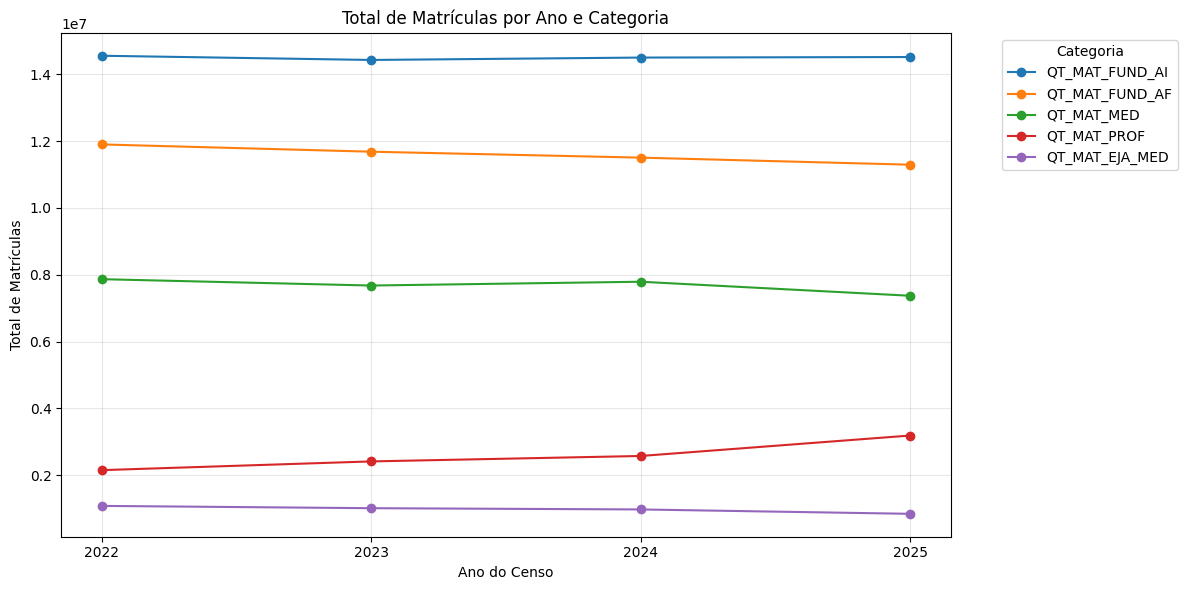


Tabela de matrículas por ano:
           QT_MAT_FUND_AI  QT_MAT_FUND_AF  QT_MAT_MED  QT_MAT_PROF  \
ANO_CENSO                                                            
2022           14553030.0      11899198.0   7866695.0    2152506.0   
2023           14426650.0      11681558.0   7676743.0    2413825.0   
2024           14498233.0      11504123.0   7790396.0    2576293.0   
2025           14514244.0      11292523.0   7370879.0    3187976.0   

           QT_MAT_EJA_MED  
ANO_CENSO                  
2022            1082607.0  
2023            1014011.0  
2024             976390.0  
2025             845627.0  


In [11]:
import matplotlib.pyplot as plt

# Colunas de matrícula a serem analisadas
colunas_matricula = [
    'QT_MAT_FUND_AI',      # Fundamental anos iniciais
    'QT_MAT_FUND_AF',      # Fundamental anos finais
    'QT_MAT_MED',          # Ensino médio
    'QT_MAT_PROF',         # Ensino profissionalizante
    'QT_MAT_EJA_MED'       # EJA ensino médio
]

# Verificar quais colunas existem no dataframe
colunas_existentes = [col for col in colunas_matricula if col in df_total.columns]
print(f"Colunas encontradas: {colunas_existentes}")

if colunas_existentes:
    # Agrupar por ano e somar as matrículas
    matriculas_por_ano = df_total.groupby('ANO_CENSO')[colunas_existentes].sum()
    
    # Plotar gráfico de linhas
    plt.figure(figsize=(12, 6))
    for coluna in colunas_existentes:
        plt.plot(matriculas_por_ano.index, matriculas_por_ano[coluna], marker='o', label=coluna)
    
    plt.title('Total de Matrículas por Ano e Categoria')
    plt.xlabel('Ano do Censo')
    plt.ylabel('Total de Matrículas')
    plt.legend(title='Categoria', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.xticks(matriculas_por_ano.index)
    plt.tight_layout()
    plt.show()
    
    # Exibir tabela com valores
    print("\nTabela de matrículas por ano:")
    print(matriculas_por_ano)
else:
    print("Nenhuma das colunas de matrícula especificadas foi encontrada no dataframe.")